<a href="https://colab.research.google.com/github/RamashrayS/Space_Anamoly_Detection_Model/blob/main/Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Based Autonomous Decision System for Deep Space Missions

## Objective
To detect anomalies in spacecraft sensor data and generate automated decisions using machine learning.

## Approach
- Used Isolation Forest for anomaly detection
- Applied on time-series sensor data
- Built a simple decision system

## Tools Used
- Python
- Pandas
- Scikit-learn
- Matplotlib

## Methodology

Isolation Forest is used to detect anomalies.
It works by identifying data points that are different from the majority.

Steps:
1. Load dataset
2. Train Isolation Forest model
3. Predict anomalies
4. Generate decisions
5. Visualize results

## Results

- The model successfully detected anomalies in the dataset
- Anomalies are highlighted in the graph
- The system generates alerts for abnormal behavior

This approach can be applied in spacecraft systems for real-time monitoring.

## Conclusion

An AI-based anomaly detection system was developed using Isolation Forest.
The system can detect abnormal sensor behavior and provide decision support.

This can help in deep space missions where communication delay makes real-time human intervention difficult.

In [8]:
import numpy as np
import pandas as pd

# create fake sensor data
data = np.random.randn(1000, 5)

df = pd.DataFrame(data, columns=['sensor1', 'sensor2', 'sensor3', 'sensor4', 'sensor5'])

df.head()

,sensor1,sensor2,sensor3,sensor4,sensor5
0,0.283907,0.708243,-2.534984,-1.786598,-0.466563
1,1.277153,-0.302523,0.021945,-2.308403,-0.292819
2,0.002977,-0.257115,-0.224123,1.026754,-2.066731
3,1.824755,0.867492,-0.073912,-1.568945,0.225478
4,-0.883354,-0.916000,0.465516,-0.286862,0.071154


In [9]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05)

df['anomaly'] = model.fit_predict(df)

df['anomaly'].value_counts()

,count
anomaly,
1,950
-1,50


In [10]:
def decision(row):
    if row['anomaly'] == -1:
        return "ALERT: Possible failure"
    return "Normal"

df['decision'] = df.apply(decision, axis=1)

df.head()

,sensor1,sensor2,sensor3,sensor4,sensor5,anomaly,decision
0,0.283907,0.708243,-2.534984,-1.786598,-0.466563,1,Normal
1,1.277153,-0.302523,0.021945,-2.308403,-0.292819,1,Normal
2,0.002977,-0.257115,-0.224123,1.026754,-2.066731,1,Normal
3,1.824755,0.867492,-0.073912,-1.568945,0.225478,1,Normal
4,-0.883354,-0.916000,0.465516,-0.286862,0.071154,1,Normal


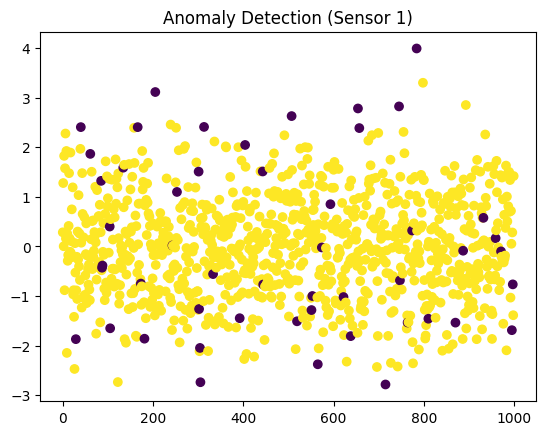

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df.index, df['sensor1'], c=df['anomaly'])
plt.title("Anomaly Detection (Sensor 1)")
plt.show()

In [12]:
import pandas as pd

# Load a simple time-series dataset (simulated spacecraft-like)
url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/ambient_temperature_system_failure.csv"

df = pd.read_csv(url)

df.head()

,timestamp,value
0,2013-07-04 00:00:00,69.880835
1,2013-07-04 01:00:00,71.220227
2,2013-07-04 02:00:00,70.877805
3,2013-07-04 03:00:00,68.959400
4,2013-07-04 04:00:00,69.283551


In [13]:
from sklearn.ensemble import IsolationForest

# use only sensor values
X = df[['value']]

model = IsolationForest(contamination=0.05)

df['anomaly'] = model.fit_predict(X)

df.head()

,timestamp,value,anomaly
0,2013-07-04 00:00:00,69.880835,1
1,2013-07-04 01:00:00,71.220227,1
2,2013-07-04 02:00:00,70.877805,1
3,2013-07-04 03:00:00,68.959400,1
4,2013-07-04 04:00:00,69.283551,1


In [14]:
def decision(row):
    if row['anomaly'] == -1:
        return "ALERT: Possible failure"
    return "Normal"

df['decision'] = df.apply(decision, axis=1)

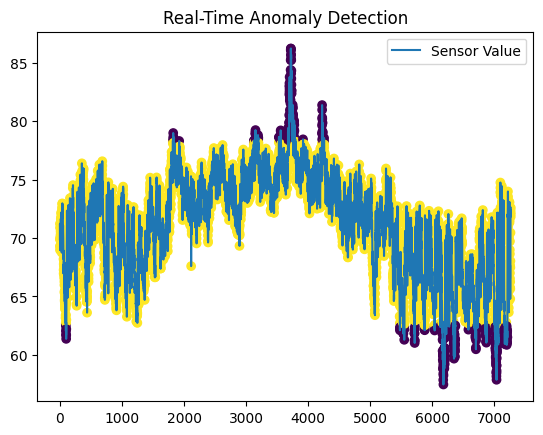

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df['value'], label='Sensor Value')
plt.scatter(df.index, df['value'], c=df['anomaly'])
plt.title("Real-Time Anomaly Detection")
plt.legend()
plt.show()